In [1]:
import h5py
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from gwpy.timeseries import TimeSeries
from gwpy.frequencyseries import FrequencySeries
from ripple.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc

## Load generated data

True, time-delayed O3a detector noise plus an injected synthetic signal.
Truth parameters are kept under `/truth` for cross-checks.

In [2]:
arrays = {}
with h5py.File("example_data/data_BBH_highSNR.h5", "r") as f:
    f.visititems(
        lambda name, obj: arrays.update({name: obj[...]})
        if isinstance(obj, h5py.Dataset) else None
    )

for name, arr in arrays.items():
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}")

ifo = "H1"
color = {"H1": "#ee0000", "L1": "#4ba6ff"}[ifo]
fs = 4096
N = arrays[f"{ifo}/strain"].shape[0]


H1/psd: shape=(16385,), dtype=float64
H1/strain: shape=(32768,), dtype=float32
L1/psd: shape=(16385,), dtype=float64
L1/strain: shape=(32768,), dtype=float32
antenna/H1/fcross: shape=(), dtype=float64
antenna/H1/fplus: shape=(), dtype=float64
antenna/L1/fcross: shape=(), dtype=float64
antenna/L1/fplus: shape=(), dtype=float64
truth/chi1: shape=(), dtype=float32
truth/chi2: shape=(), dtype=float32
truth/chirp_mass: shape=(), dtype=float32
truth/dec: shape=(), dtype=float32
truth/distance: shape=(), dtype=float32
truth/inclination: shape=(), dtype=float32
truth/mass_1: shape=(), dtype=float32
truth/mass_2: shape=(), dtype=float32
truth/mass_ratio: shape=(), dtype=float32
truth/phi: shape=(), dtype=float32
truth/phic: shape=(), dtype=float32
truth/psi: shape=(), dtype=float32
truth/s1z: shape=(), dtype=float32
truth/s2z: shape=(), dtype=float32
truth/snr: shape=(), dtype=float32
truth/snr_H1: shape=(), dtype=float32
truth/snr_L1: shape=(), dtype=float32
truth/tc: shape=(), dtype=float64


## Inputs in time and frequency space

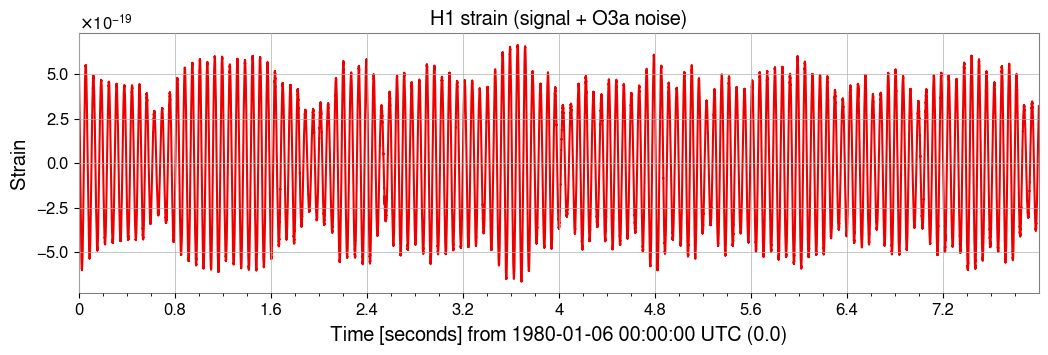

In [3]:
strain_ts = TimeSeries(arrays[f"{ifo}/strain"], t0=0, sample_rate=fs)
psd_fs = FrequencySeries(arrays[f"{ifo}/psd"], f0=0, df=fs / N)

strain_ts.plot(
    title=f"{ifo} strain (signal + O3a noise)", ylabel="Strain", color=color,
).show()

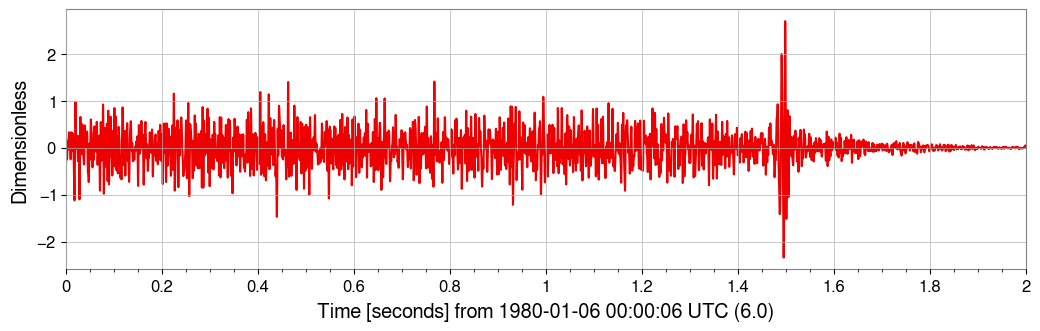

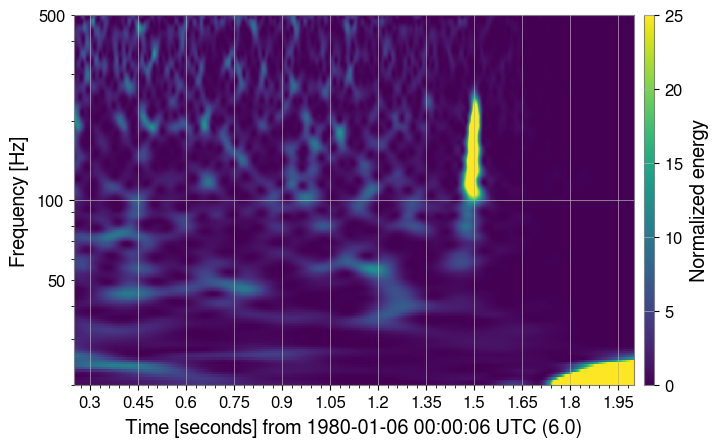

In [4]:
white = strain_ts.whiten(asd=psd_fs ** 0.5).bandpass(30, 400)
plot = white.plot(color=color)
plot.gca().set_xlim(6.0, 8.0)
plot.show()

qtrans = white.q_transform(frange=(20, 500), outseg=(6.25, 8), whiten=False)
plot = qtrans.plot(figsize=(8, 5), vmin=0, vmax=25)
ax = plot.gca()
ax.set_yscale("log")
ax.set_ylabel("Frequency [Hz]")
plot.colorbar(label="Normalized energy")
plot.show()

## Matched filtering

Build `d_full` and `h_full` on the segment rFFT grid, then run the proper
matched filter against the stored PSD as a baseline.

In [5]:
df = fs / N
freqs = jnp.fft.rfftfreq(N, d=1.0 / fs)
band = (freqs >= 20) & (freqs <= fs / 2)
f_ref = 20.0

strain = jnp.asarray(np.asarray(strain_ts))
psd_arr = jnp.asarray(np.asarray(psd_fs))

# Truth parameters in ripple's BBH order: [Mc, eta, chi1, chi2, D, tc, phic, iota].
q = float(arrays["truth/mass_ratio"])
theta_truth = jnp.array([
    float(arrays["truth/chirp_mass"]),
    q / (1 + q) ** 2,
    float(arrays["truth/chi1"]),
    float(arrays["truth/chi2"]),
    float(arrays["truth/distance"]),
    float(arrays["truth/tc"]),
    float(arrays["truth/phic"]),
    float(arrays["truth/inclination"]),
])

# Template on the rFFT grid, projected through this IFO's antenna factors.
fplus = float(arrays[f"antenna/{ifo}/fplus"])
fcross = float(arrays[f"antenna/{ifo}/fcross"])
hp, hc = gen_IMRPhenomD_hphc(freqs[band].astype(jnp.float64), theta_truth, f_ref)
h_band = (fplus * hp + fcross * hc).astype(jnp.complex128)
h_full = jnp.zeros_like(freqs, dtype=jnp.complex128).at[band].set(h_band)

# Tukey(alpha=0.01) on the strain matches the PSD's segment-edge treatment
# without eating the merger (only the first/last 1% of samples are tapered).
n_tukey = int(round(0.01 * N / 2))
ramp = 0.5 * (1 - jnp.cos(jnp.pi * (jnp.arange(n_tukey) + 0.5) / n_tukey))
window_td = jnp.concatenate([ramp, jnp.ones(N - 2 * n_tukey), ramp[::-1]])
d_full = jnp.fft.rfft(strain * window_td) / fs

psd_safe = jnp.where(band, psd_arr, jnp.inf)

In [6]:
inner_hh = 4.0 * df * jnp.real(jnp.sum(jnp.abs(h_full) ** 2 / psd_safe))
truth_snr = float(arrays[f"truth/snr_{ifo}"])
print(f"sqrt<h|h> (stored PSD): {float(jnp.sqrt(inner_hh)):.3f}")
print(f"truth {ifo} SNR        : {truth_snr:.3f}")

sqrt<h|h> (stored PSD): 30.905
truth H1 SNR        : 30.905


## Matched filter


In [7]:
# z(t) = 4 ∫ conj(d̃) h̃ e^{2πift} / S_n(f) df          # cross-correlation vs shift
# ρ(t) = |z(t)| / sqrt(<h|h>)                            # phase-maximised SNR
#
# Zero-pad the one-sided integrand back to a full length-N complex spectrum
# (negative freqs = 0) before the inverse FFT, so the 4 · fs factor matches
# the continuous-time matched-filter normalisation.
integrand = jnp.conj(d_full) * h_full / psd_safe
z_t = 4.0 * fs * jnp.fft.ifft(
    jnp.zeros(N, dtype=jnp.complex128).at[: integrand.shape[0]].set(integrand)
)
rho_t = jnp.abs(z_t) / jnp.sqrt(inner_hh)
peak_idx = int(jnp.argmax(rho_t))

# The ifft index encodes the *relative* shift τ_peak between data and template,
# with periodic wrap-around: indices > N/2 map to negative shifts. The
# recovered coalescence time in the data is then
#     tc_data = tc_template − τ_peak
tau_peak = (peak_idx if peak_idx < N // 2 else peak_idx - N) / fs
tc_recovered = float(theta_truth[5]) - tau_peak

print(f"<h|h>                : {float(inner_hh):.3f}")
print(f"Matched-filter peak  : {float(rho_t[peak_idx]):.3f}")
print(f"  shift τ_peak       : {tau_peak * 1e3:+.3f} ms")
print(f"  recovered tc       : {tc_recovered:.4f} s   (truth tc: {float(theta_truth[5]):.4f} s)")
print(f"True {ifo} SNR          : {truth_snr:.3f}")


<h|h>                : 955.117
Matched-filter peak  : 32.024
  shift τ_peak       : -13.672 ms
  recovered tc       : 7.5137 s   (truth tc: 7.5000 s)
True H1 SNR          : 30.905


## Fit chirp mass with JAX

Regenerate the template at each Mc and gradient-descend on
`-max_t |z(t)|² / <h|h>`. Time-maximising via ifft removes the
need to also fit tc, because as Mc moves the merger drifts inside the
segment and `max_t` tracks it automatically.

In [8]:
def template(theta):
    hp, hc = gen_IMRPhenomD_hphc(freqs[band].astype(jnp.float64), theta, f_ref)
    h_b = (fplus * hp + fcross * hc).astype(jnp.complex128)
    return jnp.zeros_like(freqs, dtype=jnp.complex128).at[band].set(h_b)


@jax.jit
@jax.value_and_grad
def differential_matched_filter(mc):
    theta = theta_truth.at[0].set(mc)
    h = template(theta)
    hh = 4.0 * df * jnp.real(jnp.sum(jnp.abs(h) ** 2 / psd_safe))
    integrand = jnp.conj(d_full) * h / psd_safe
    pad = jnp.zeros(N, dtype=jnp.complex128).at[: integrand.shape[0]].set(integrand)
    z = 4.0 * fs * jnp.fft.ifft(pad)
    return -(jnp.max(jnp.abs(z) ** 2) / hh)

In [9]:
mc_truth = float(theta_truth[0])
mc = jnp.float64(mc_truth + 1.0)     
schedule = optax.cosine_decay_schedule(init_value=0.1, decay_steps=300, alpha=1e-3 / 0.1)
opt = optax.adam(schedule)
state = opt.init(mc)

hist_mc, hist_rho_mc = [], []
for _ in range(300):
    loss, g = differential_matched_filter(mc)
    hist_mc.append(float(mc))
    hist_rho_mc.append(float(jnp.sqrt(-loss)))
    if not np.isfinite(g):
        print(f"non-finite gradient at Mc = {float(mc):.4f}; stopping")
        break
    updates, state = opt.update(g, state)
    mc = optax.apply_updates(mc, updates)

print(f"Initial Mc : {hist_mc[0]:.4f} Msun   →  ρ = {hist_rho_mc[0]:.3f}")
print(f"Final   Mc : {hist_mc[-1]:.4f} Msun   →  ρ = {hist_rho_mc[-1]:.3f}")
print(f"Truth   Mc : {mc_truth:.4f} Msun         (truth ρ = {truth_snr:.3f})")

Initial Mc : 33.4014 Msun   →  ρ = 32.017
Final   Mc : 32.8461 Msun   →  ρ = 32.038
Truth   Mc : 32.4014 Msun         (truth ρ = 30.905)


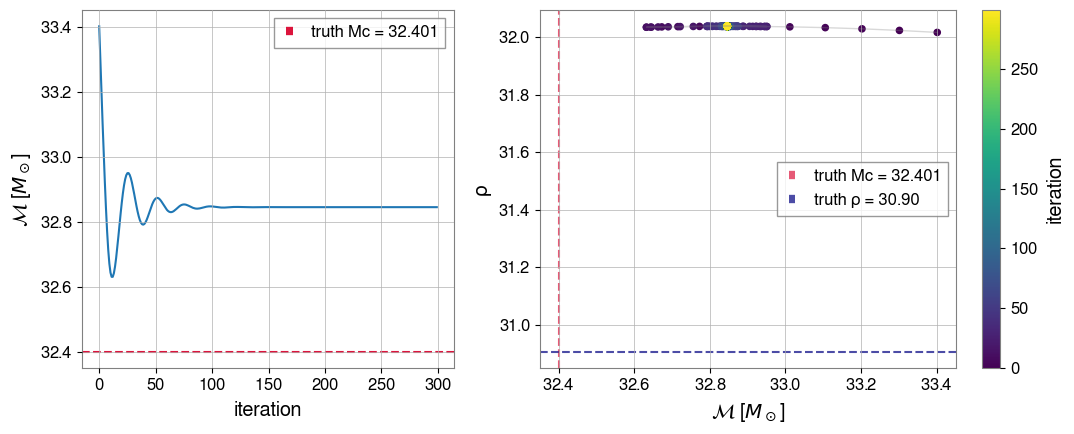

In [10]:
iters = np.arange(len(hist_mc))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5),
                               gridspec_kw={"width_ratios": [1, 1.4]})
ax0.plot(iters, hist_mc, color="C0")
ax0.axhline(mc_truth, ls="--", color="crimson", label=f"truth Mc = {mc_truth:.3f}")
ax0.set_xlabel("iteration"); ax0.set_ylabel(r"$\mathcal{M}$ [$M_\odot$]"); ax0.legend()

sc = ax1.scatter(hist_mc, hist_rho_mc, c=iters, cmap="viridis", s=20)
ax1.plot(hist_mc, hist_rho_mc, color="gray", alpha=0.3, lw=1)
ax1.axvline(mc_truth, ls="--", color="crimson", alpha=0.7, label=f"truth Mc = {mc_truth:.3f}")
ax1.axhline(truth_snr, ls="--", color="navy", alpha=0.7, label=f"truth ρ = {truth_snr:.2f}")
ax1.set_xlabel(r"$\mathcal{M}$ [$M_\odot$]"); ax1.set_ylabel("ρ"); ax1.legend()
fig.colorbar(sc, ax=ax1, label="iteration")
fig.tight_layout(); plt.show()

## Fit arrival time tc (only)

In [11]:
# Fit the arrival time only. Phase-shift h_full by exp(-2πi·f·Δtc)
# (FT shift theorem — no template regeneration) and gradient-descend on
# -|<d|h_Δtc>|²/<h|h>. Basin of the phase-maximised SNR² is ~1/f_max
# (≈ a couple of ms here), so start a few hundred microseconds off-truth.
@jax.jit
@jax.value_and_grad
def differential_matched_filter_tc(delta_tc):
    h_shifted = h_full * jnp.exp(-2j * jnp.pi * freqs * delta_tc)
    dh = 4.0 * df * jnp.sum(jnp.conj(d_full) * h_shifted / psd_safe)
    return -(jnp.abs(dh) ** 2 / inner_hh)

dtc = jnp.float64(5e-4)             
opt = optax.adam(1e-5)
state = opt.init(dtc)

hist_dtc, hist_rho_tc = [], []
for _ in range(500):
    loss, g = differential_matched_filter_tc(dtc)
    hist_dtc.append(float(dtc))
    hist_rho_tc.append(float(jnp.sqrt(-loss)))
    updates, state = opt.update(g, state)
    dtc = optax.apply_updates(dtc, updates)

tc_template = float(theta_truth[5])
print(f"Initial Δtc : {hist_dtc[0] * 1e3:+.3f} ms   →  ρ = {hist_rho_tc[0]:.3f}")
print(f"Final   Δtc : {hist_dtc[-1] * 1e3:+.3f} ms   →  ρ = {hist_rho_tc[-1]:.3f}")
print(f"Recovered tc: {tc_template + float(dtc):.4f} s   (truth: {tc_template:.4f} s)")

Initial Δtc : +0.500 ms   →  ρ = 0.755
Final   Δtc : +4.250 ms   →  ρ = 2.550
Recovered tc: 7.5043 s   (truth: 7.5000 s)


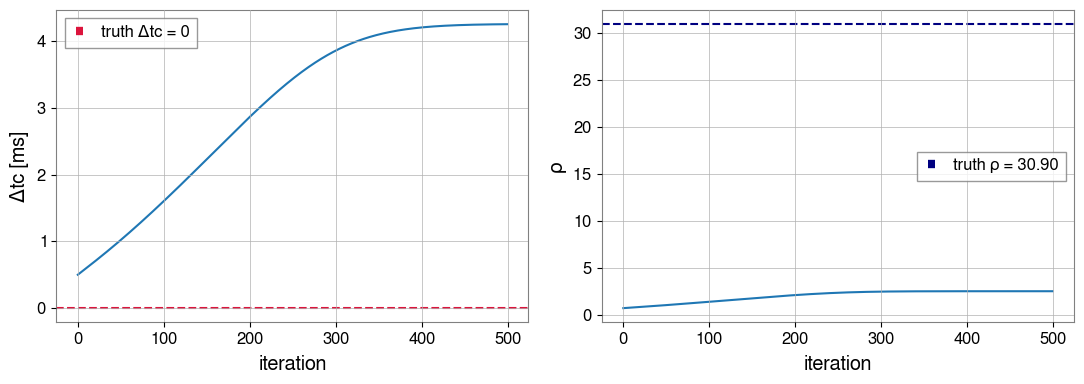

In [12]:
iters_tc = np.arange(len(hist_dtc))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))
ax0.plot(iters_tc, np.array(hist_dtc) * 1e3, color="C0")
ax0.axhline(0, ls="--", color="crimson", label="truth Δtc = 0")
ax0.set_xlabel("iteration"); ax0.set_ylabel("Δtc [ms]"); ax0.legend()
ax1.plot(iters_tc, hist_rho_tc, color="C0")
ax1.axhline(truth_snr, ls="--", color="navy", label=f"truth ρ = {truth_snr:.2f}")
ax1.set_xlabel("iteration"); ax1.set_ylabel("ρ"); ax1.legend()
fig.tight_layout(); plt.show()

## Simultenous Fit of chirp mass and merger time

In [13]:
# Joint fit of (Mc, Δtc). Phase-maximised SNR² (no time-max), so Δtc has a
# real gradient signal — otherwise the ifft's max_t would absorb it and the
# joint fit would collapse back to Mc-only. 

@jax.jit
@jax.value_and_grad
def differential_matched_filter_joint(params):
    mc, dtc = params
    theta = theta_truth.at[0].set(mc)
    h = template(theta) * jnp.exp(-2j * jnp.pi * freqs * dtc)
    dh = 4.0 * df * jnp.sum(jnp.conj(d_full) * h / psd_safe)
    hh = 4.0 * df * jnp.real(jnp.sum(jnp.abs(h) ** 2 / psd_safe))
    return -(jnp.abs(dh) ** 2 / hh)

params = jnp.array([mc_truth + 0.1, 3e-4], dtype=jnp.float64)  # +0.3 Msun, +0.3 ms
schedule = optax.cosine_decay_schedule(init_value=0.05, decay_steps=500, alpha=1e-3 / 0.05)
opt = optax.adam(schedule)
state = opt.init(params)

hist_mc_j, hist_dtc_j, hist_rho_j = [], [], []
for _ in range(500):
    loss, g = differential_matched_filter_joint(params)
    hist_mc_j.append(float(params[0]))
    hist_dtc_j.append(float(params[1]))
    hist_rho_j.append(float(jnp.sqrt(-loss)))
    if not jnp.all(jnp.isfinite(g)):
        print(f"non-finite gradient at Mc = {float(params[0]):.4f}; stopping")
        break
    updates, state = opt.update(g, state)
    params = optax.apply_updates(params, updates)

print(f"Initial: Mc = {hist_mc_j[0]:.4f}  Δtc = {hist_dtc_j[0] * 1e3:+.3f} ms  ρ = {hist_rho_j[0]:.3f}")
print(f"Final  : Mc = {hist_mc_j[-1]:.4f}  Δtc = {hist_dtc_j[-1] * 1e3:+.3f} ms  ρ = {hist_rho_j[-1]:.3f}")
print(f"Truth  : Mc = {mc_truth:.4f}  Δtc = +0.000 ms         ρ = {truth_snr:.3f}")

Initial: Mc = 32.5014  Δtc = +0.300 ms  ρ = 0.667
Final  : Mc = 31.4438  Δtc = -279.503 ms  ρ = 2.440
Truth  : Mc = 32.4014  Δtc = +0.000 ms         ρ = 30.905


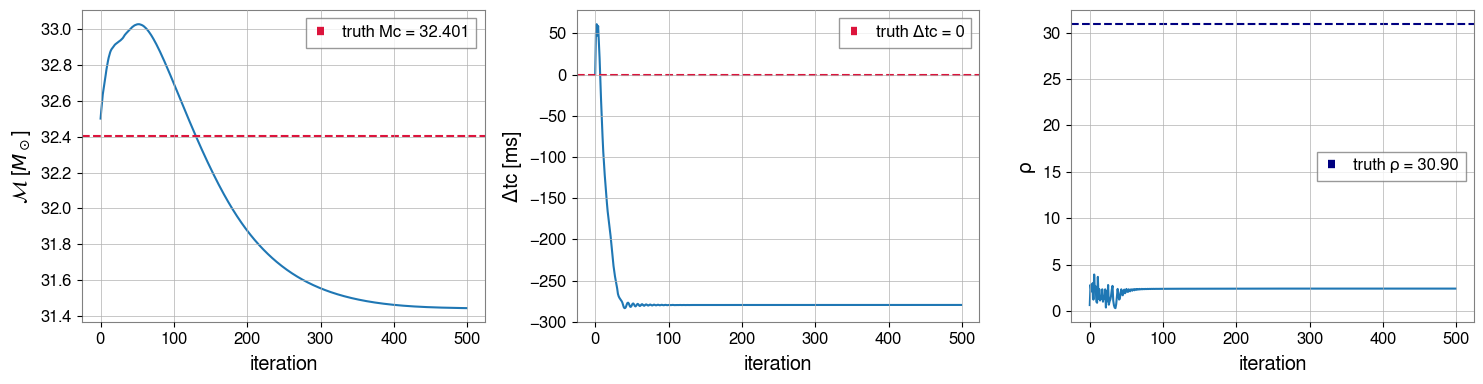

In [14]:
iters_j = np.arange(len(hist_mc_j))
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 4))
ax0.plot(iters_j, hist_mc_j, color="C0")
ax0.axhline(mc_truth, ls="--", color="crimson", label=f"truth Mc = {mc_truth:.3f}")
ax0.set_xlabel("iteration"); ax0.set_ylabel(r"$\mathcal{M}$ [$M_\odot$]"); ax0.legend()

ax1.plot(iters_j, np.array(hist_dtc_j) * 1e3, color="C0")
ax1.axhline(0.0, ls="--", color="crimson", label="truth Δtc = 0")
ax1.set_xlabel("iteration"); ax1.set_ylabel("Δtc [ms]"); ax1.legend()

ax2.plot(iters_j, hist_rho_j, color="C0")
ax2.axhline(truth_snr, ls="--", color="navy", label=f"truth ρ = {truth_snr:.2f}")
ax2.set_xlabel("iteration"); ax2.set_ylabel("ρ"); ax2.legend()
fig.tight_layout(); plt.show()

## Fitting the network of both detectors

In [15]:
# Network fit: sum time-maximised ρ² across H1 and L1. Build per-IFO
# (d_full, psd_safe, F+, Fx) from the loaded HDF5 — same Tukey window on
# the strain as the single-IFO setup, each detector's own antenna factors.
detectors = {}
for det in ("H1", "L1"):
    ts_det = TimeSeries(arrays[f"{det}/strain"], t0=0, sample_rate=fs)
    strain_det = jnp.asarray(np.asarray(ts_det))
    psd_det = jnp.asarray(arrays[f"{det}/psd"])
    detectors[det] = {
        "d_full": jnp.fft.rfft(strain_det * window_td) / fs,
        "psd_safe": jnp.where(band, psd_det, jnp.inf),
        "fplus": float(arrays[f"antenna/{det}/fplus"]),
        "fcross": float(arrays[f"antenna/{det}/fcross"]),
    }

truth_snr_net = float(arrays["truth/snr"])

def _rho_sq_det(theta, det):
    hp_, hc_ = gen_IMRPhenomD_hphc(freqs[band].astype(jnp.float64), theta, f_ref)
    h_b = (det["fplus"] * hp_ + det["fcross"] * hc_).astype(jnp.complex128)
    h = jnp.zeros_like(freqs, dtype=jnp.complex128).at[band].set(h_b)
    hh = 4.0 * df * jnp.real(jnp.sum(jnp.abs(h) ** 2 / det["psd_safe"]))
    integrand = jnp.conj(det["d_full"]) * h / det["psd_safe"]
    pad = jnp.zeros(N, dtype=jnp.complex128).at[: integrand.shape[0]].set(integrand)
    z = 4.0 * fs * jnp.fft.ifft(pad)
    return jnp.max(jnp.abs(z) ** 2) / hh

@jax.jit
@jax.value_and_grad
def differential_matched_filter_network(mc):
    theta = theta_truth.at[0].set(mc)
    return -(_rho_sq_det(theta, detectors["H1"])
             + _rho_sq_det(theta, detectors["L1"]))

mc = jnp.float64(mc_truth + 10.0)     
schedule = optax.cosine_decay_schedule(init_value=0.1, decay_steps=300, alpha=1e-3 / 0.1)
opt = optax.adam(schedule)
state = opt.init(mc)

hist_mc_n, hist_rho_net = [], []
for _ in range(500):
    loss, g = differential_matched_filter_network(mc)
    hist_mc_n.append(float(mc))
    hist_rho_net.append(float(jnp.sqrt(-loss)))
    if not np.isfinite(g):
        print(f"non-finite gradient at Mc = {float(mc):.4f}; stopping")
        break
    updates, state = opt.update(g, state)
    mc = optax.apply_updates(mc, updates)

print(f"Initial Mc : {hist_mc_n[0]:.4f} Msun   →  ρ_net = {hist_rho_net[0]:.3f}")
print(f"Final   Mc : {hist_mc_n[-1]:.4f} Msun   →  ρ_net = {hist_rho_net[-1]:.3f}")
print(f"Truth   Mc : {mc_truth:.4f} Msun           (truth ρ_net = {truth_snr_net:.3f})")

Initial Mc : 42.4014 Msun   →  ρ_net = 56.128
Final   Mc : 32.4414 Msun   →  ρ_net = 63.596
Truth   Mc : 32.4014 Msun           (truth ρ_net = 63.723)


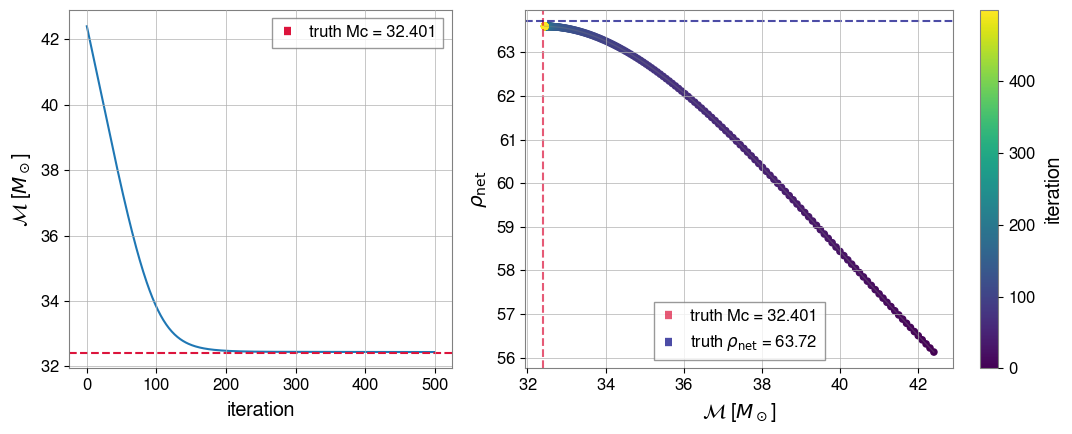

In [16]:
iters_n = np.arange(len(hist_mc_n))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5),
                               gridspec_kw={"width_ratios": [1, 1.4]})
ax0.plot(iters_n, hist_mc_n, color="C0")
ax0.axhline(mc_truth, ls="--", color="crimson", label=f"truth Mc = {mc_truth:.3f}")
ax0.set_xlabel("iteration"); ax0.set_ylabel(r"$\mathcal{M}$ [$M_\odot$]"); ax0.legend()

sc = ax1.scatter(hist_mc_n, hist_rho_net, c=iters_n, cmap="viridis", s=20)
ax1.plot(hist_mc_n, hist_rho_net, color="gray", alpha=0.3, lw=1)
ax1.axvline(mc_truth, ls="--", color="crimson", alpha=0.7, label=f"truth Mc = {mc_truth:.3f}")
ax1.axhline(truth_snr_net, ls="--", color="navy", alpha=0.7,
            label=fr"truth $\rho_\mathrm{{net}}$ = {truth_snr_net:.2f}")
ax1.set_xlabel(r"$\mathcal{M}$ [$M_\odot$]"); ax1.set_ylabel(r"$\rho_\mathrm{net}$"); ax1.legend()
fig.colorbar(sc, ax=ax1, label="iteration")
fig.tight_layout(); plt.show()

## Network fit with PyTorch + ml4gw waveforms

The network fit above used JAX + `optax` to differentiate a `ripple`
waveform. Here the *identical* network chirp-mass fit is rebuilt on
PyTorch autograd with `ml4gw.waveforms.IMRPhenomD` as the template —
the same waveform model `GWDatasetGeneration` uses to *make* the BBH
injections.

Two small shims are needed because `ml4gw`'s `IMRPhenomD` is written for
forward evaluation, not differentiation:

- `torch.heaviside` has no autograd rule. The waveform only uses it to
  build piecewise-constant PN-region masks, whose derivative is 0 almost
  everywhere, so a detached version is substituted.
- `phenom_d_mrd_amp` multiplies an `exp(...)` output in place, which
  corrupts that op's backward pass. The method is monkeypatched with an
  out-of-place equivalent.

`ml4gw`'s template amplitude differs from `ripple`'s by an overall
constant, but the matched-filter SNR `ρ = |⟨d|h⟩| / √⟨h|h⟩` is
normalised, so the constant cancels and the recovered chirp mass and
network SNR come out the same as the JAX fit.

In [17]:
import torch
from ml4gw.waveforms import IMRPhenomD

torch.set_default_dtype(torch.float64)

# --- shim 1: torch.heaviside has no autograd rule. ml4gw only uses it to
# build piecewise-constant PN-region masks, whose derivative is 0 almost
# everywhere, so a detached version is the correct gradient. ---
_orig_heaviside = torch.heaviside
torch.heaviside = lambda inp, val: _orig_heaviside(inp.detach(), val.detach())

# --- shim 2: ml4gw's phenom_d_mrd_amp does `exp(...) *= ...` in place,
# which corrupts that exp's backward pass. Re-bind an out-of-place copy. ---
def _phenom_d_mrd_amp(self, Mf, eta, eta2, chi1, chi2, xi, fRD, fDM):
    g1 = self.gamma1_fun(eta, eta2, xi)
    g2 = self.gamma2_fun(eta, eta2, xi)
    g3 = self.gamma3_fun(eta, eta2, xi)
    fDMg3 = fDM * g3
    pow2 = (torch.ones_like(Mf).mT * fDMg3 * fDMg3).mT
    fminfRD = Mf - (torch.ones_like(Mf).mT * fRD).mT
    etl = torch.exp(fminfRD.mT * g2 / fDMg3).mT
    etl = etl * (fminfRD ** 2 + pow2)            # upstream uses `*=` here
    amp = (1 / etl.mT * g1 * g3 * fDM).mT
    Damp = (fminfRD.mT * -2 * fDM * g1 * g3) / (
        fminfRD * fminfRD + pow2
    ).mT - (g2 * g1)
    return amp, Damp.mT / etl

IMRPhenomD.phenom_d_mrd_amp = _phenom_d_mrd_amp

# --- per-detector matched-filter inputs as torch tensors ---
N_t = arrays["H1/strain"].shape[0]
df_t = fs / N_t
f_ref_t = 20.0
freqs_t = torch.fft.rfftfreq(N_t, d=1.0 / fs)
band_t = (freqs_t >= 20) & (freqs_t <= fs / 2)
band_idx = band_t.nonzero().squeeze()

# Tukey(alpha=0.01) on the strain — same window as the JAX path above.
n_tukey_t = int(round(0.01 * N_t / 2))
ramp_t = 0.5 * (1 - torch.cos(
    torch.pi * (torch.arange(n_tukey_t) + 0.5) / n_tukey_t))
window_t = torch.cat([ramp_t, torch.ones(N_t - 2 * n_tukey_t), ramp_t.flip(0)])

detectors_t = {}
for det in ("H1", "L1"):
    strain_det = torch.tensor(arrays[f"{det}/strain"], dtype=torch.float64)
    psd_det = torch.tensor(arrays[f"{det}/psd"], dtype=torch.float64)
    detectors_t[det] = {
        "d_full": torch.fft.rfft(strain_det * window_t) / fs,
        "psd_safe": torch.where(band_t, psd_det, torch.inf),
        "fplus": float(arrays[f"antenna/{det}/fplus"]),
        "fcross": float(arrays[f"antenna/{det}/fcross"]),
    }

# ml4gw's IMRPhenomD takes `mass_ratio` directly (no eta) and has no `tc`
# argument — the matched filter's max_t already absorbs the arrival time.
# Non-mass parameters are held fixed at their truth values.
phenom = IMRPhenomD()
def _const(v):
    return torch.tensor([float(v)], dtype=torch.float64)

fixed_params = dict(
    mass_ratio=_const(arrays["truth/mass_ratio"]),
    chi1=_const(arrays["truth/chi1"]),
    chi2=_const(arrays["truth/chi2"]),
    distance=_const(arrays["truth/distance"]),
    phic=_const(arrays["truth/phic"]),
    inclination=_const(arrays["truth/inclination"]),
)
mc_truth_t = float(arrays["truth/chirp_mass"])
truth_snr_net_t = float(arrays["truth/snr"])

In [18]:
def network_loss_torch(mc):
    """-(ρ²_H1 + ρ²_L1), each ρ² time-maximised with one inverse FFT.

    Same statistic as `differential_matched_filter_network` above, but
    differentiated by PyTorch autograd instead of `jax.value_and_grad`.
    """
    hc, hp = phenom(freqs_t[band_t], chirp_mass=mc, f_ref=f_ref_t, **fixed_params)
    rho_sq = mc.new_zeros(())
    for det in detectors_t.values():
        h_band = det["fplus"] * hp[0] + det["fcross"] * hc[0]
        h = torch.zeros(N_t // 2 + 1, dtype=torch.complex128).index_put(
            (band_idx,), h_band
        )
        hh = 4.0 * df_t * torch.sum(torch.abs(h) ** 2 / det["psd_safe"]).real
        integrand = torch.conj(det["d_full"]) * h / det["psd_safe"]
        pad = torch.zeros(N_t, dtype=torch.complex128).index_put(
            (torch.arange(integrand.shape[0]),), integrand
        )
        z = 4.0 * fs * torch.fft.ifft(pad)
        rho_sq = rho_sq + torch.max(torch.abs(z) ** 2) / hh
    return -rho_sq


mc_torch = torch.tensor([mc_truth_t + 10.0], dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([mc_torch], lr=0.1)
schedule = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=500, eta_min=1e-3)

hist_mc_torch, hist_rho_torch = [], []
for _ in range(500):
    opt.zero_grad()
    loss = network_loss_torch(mc_torch)
    loss.backward()
    hist_mc_torch.append(mc_torch.item())
    hist_rho_torch.append(float(torch.sqrt(-loss.detach())))
    opt.step()
    schedule.step()

print(f"Initial Mc : {hist_mc_torch[0]:.4f} Msun   →  ρ_net = {hist_rho_torch[0]:.3f}")
print(f"Final   Mc : {hist_mc_torch[-1]:.4f} Msun   →  ρ_net = {hist_rho_torch[-1]:.3f}")
print(f"Truth   Mc : {mc_truth_t:.4f} Msun           (truth ρ_net = {truth_snr_net_t:.3f})")

Initial Mc : 42.4014 Msun   →  ρ_net = 56.128
Final   Mc : 32.4078 Msun   →  ρ_net = 63.596
Truth   Mc : 32.4014 Msun           (truth ρ_net = 63.723)


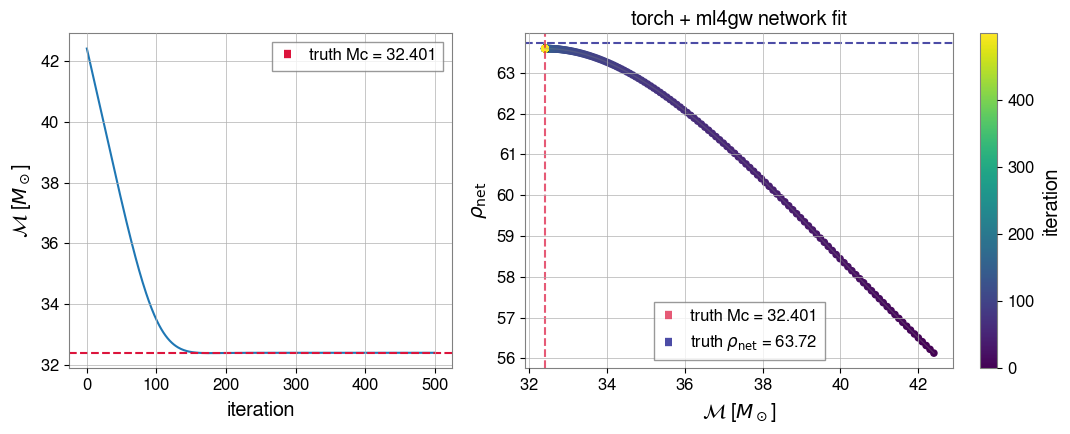

In [19]:
iters_t = np.arange(len(hist_mc_torch))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5),
                               gridspec_kw={"width_ratios": [1, 1.4]})
ax0.plot(iters_t, hist_mc_torch, color="C0")
ax0.axhline(mc_truth_t, ls="--", color="crimson", label=f"truth Mc = {mc_truth_t:.3f}")
ax0.set_xlabel("iteration"); ax0.set_ylabel(r"$\mathcal{M}$ [$M_\odot$]"); ax0.legend()

sc = ax1.scatter(hist_mc_torch, hist_rho_torch, c=iters_t, cmap="viridis", s=20)
ax1.plot(hist_mc_torch, hist_rho_torch, color="gray", alpha=0.3, lw=1)
ax1.axvline(mc_truth_t, ls="--", color="crimson", alpha=0.7,
            label=f"truth Mc = {mc_truth_t:.3f}")
ax1.axhline(truth_snr_net_t, ls="--", color="navy", alpha=0.7,
            label=fr"truth $\rho_\mathrm{{net}}$ = {truth_snr_net_t:.2f}")
ax1.set_xlabel(r"$\mathcal{M}$ [$M_\odot$]"); ax1.set_ylabel(r"$\rho_\mathrm{net}$")
ax1.legend()
ax1.set_title("torch + ml4gw network fit")
fig.colorbar(sc, ax=ax1, label="iteration")
fig.tight_layout(); plt.show()